In [1]:
import pandas as pd
df = pd.read_csv('city_day.csv')
df.shape
df.info()
df.describe()
df['City'].nunique()
df['AQI_Bucket'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


array([nan, 'Poor', 'Very Poor', 'Severe', 'Moderate', 'Satisfactory',
       'Good'], dtype=object)

In [2]:
import requests
import time

# Load your dataset
df = pd.read_csv('city_day.csv')
df['Date'] = pd.to_datetime(df['Date'])

# COMPLETE Dictionary of Coordinates for all cities in your dataset
city_coords = {
    'Ahmedabad': {'lat': 23.0225, 'lon': 72.5714},
    'Aizawl': {'lat': 23.7271, 'lon': 92.7176},
    'Amaravati': {'lat': 16.5131, 'lon': 80.5165},
    'Amritsar': {'lat': 31.6340, 'lon': 74.8723},
    'Bengaluru': {'lat': 12.9716, 'lon': 77.5946},
    'Bhopal': {'lat': 23.2599, 'lon': 77.4126},
    'Brajrajnagar': {'lat': 21.8216, 'lon': 83.9216},
    'Chandigarh': {'lat': 30.7333, 'lon': 76.7794},
    'Chennai': {'lat': 13.0827, 'lon': 80.2707},
    'Coimbatore': {'lat': 11.0168, 'lon': 76.9558},
    'Delhi': {'lat': 28.6139, 'lon': 77.2090},
    'Ernakulam': {'lat': 9.9816, 'lon': 76.2999},
    'Gurugram': {'lat': 28.4601, 'lon': 77.0199},
    'Guwahati': {'lat': 26.1445, 'lon': 91.7362},
    'Hyderabad': {'lat': 17.3850, 'lon': 78.4867},
    'Jaipur': {'lat': 26.9124, 'lon': 75.7873},
    'Jorapokhar': {'lat': 23.7004, 'lon': 86.4125},
    'Kochi': {'lat': 9.9312, 'lon': 76.2673},
    'Kolkata': {'lat': 22.5726, 'lon': 88.3639},
    'Lucknow': {'lat': 26.8467, 'lon': 80.9462},
    'Mumbai': {'lat': 19.0760, 'lon': 72.8777},
    'Patna': {'lat': 25.5941, 'lon': 85.1376},
    'Shillong': {'lat': 25.5788, 'lon': 91.8933},
    'Talcher': {'lat': 20.9509, 'lon': 85.2163},
    'Thiruvananthapuram': {'lat': 8.5241, 'lon': 76.9366},
    'Visakhapatnam': {'lat': 17.6868, 'lon': 83.2185}
}

weather_frames = []

# Fetch data using the complete list
for city in df['City'].unique():
    # Safety check in case a new city appears in future data
    if city not in city_coords:
        print(f"⚠️ Skipping {city}: Coordinates still missing.")
        continue
        
    lat = city_coords[city]['lat']
    lon = city_coords[city]['lon']
    
    # Get date range for this specific city
    city_data = df[df['City'] == city]
    start_date = city_data['Date'].min().strftime('%Y-%m-%d')
    end_date = city_data['Date'].max().strftime('%Y-%m-%d')
    
    print(f"Fetching data for {city}...")
    
    try:
        # Fetch Temperature, Humidity, and Wind Speed
        url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={start_date}&end_date={end_date}&daily=temperature_2m_mean,relative_humidity_2m_mean,wind_speed_10m_max&timezone=auto"
        
        response = requests.get(url)
        
        if response.status_code == 200:
            data = response.json()
            
            # Create a temporary dataframe for the weather data
            temp_df = pd.DataFrame({
                'Date': pd.to_datetime(data['daily']['time']),
                'City': city,
                'Temp_Mean': data['daily']['temperature_2m_mean'],
                'Humidity_Mean': data['daily']['relative_humidity_2m_mean'],
                'Wind_Speed_Max': data['daily']['wind_speed_10m_max']
            })
            weather_frames.append(temp_df)
        else:
            print(f"❌ Error fetching {city}: {response.status_code}")
            
    except Exception as e:
        print(f"❌ Exception for {city}: {e}")
    
    # Pause briefly to respect API rate limits
    time.sleep(1)

# Combine and Merge
if weather_frames:
    all_weather_df = pd.concat(weather_frames)
    
    # Merge with original data
    final_df = pd.merge(df, all_weather_df, on=['City', 'Date'], how='left')
    
    # Save to CSV
    final_df.to_csv('city_day_with_weather_complete.csv', index=False)
    print("\n✅ Success! All cities updated. Saved to 'city_day_with_weather_complete.csv'")
else:
    print("\n❌ No weather data fetched.")

Fetching data for Ahmedabad...
Fetching data for Aizawl...
Fetching data for Amaravati...
Fetching data for Amritsar...
Fetching data for Bengaluru...
Fetching data for Bhopal...
Fetching data for Brajrajnagar...
Fetching data for Chandigarh...
Fetching data for Chennai...
Fetching data for Coimbatore...
Fetching data for Delhi...
Fetching data for Ernakulam...
Fetching data for Gurugram...
Fetching data for Guwahati...
Fetching data for Hyderabad...
Fetching data for Jaipur...
Fetching data for Jorapokhar...
Fetching data for Kochi...
Fetching data for Kolkata...
Fetching data for Lucknow...
Fetching data for Mumbai...
Fetching data for Patna...
Fetching data for Shillong...
Fetching data for Talcher...
Fetching data for Thiruvananthapuram...
Fetching data for Visakhapatnam...

✅ Success! All cities updated. Saved to 'city_day_with_weather_complete.csv'


In [26]:
import pandas as pd
import numpy as np
df = pd.read_csv('city_day_with_weather_complete.csv')
df_numeric = df.select_dtypes(include=np.number)

df_numeric.head()
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Temp_Mean,Humidity_Mean,Wind_Speed_Max
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN,20.3,67,14.8
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN,20.4,65,15.6
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN,19.7,70,11.4
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN,19.8,64,13.6
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN,19.0,53,15.2


In [27]:
corr_matrix = df_numeric.corr()
print(corr_matrix)

                   PM2.5      PM10        NO       NO2       NOx       NH3  \
PM2.5           1.000000  0.846498  0.433491  0.350709  0.436792  0.275086   
PM10            0.846498  1.000000  0.502349  0.464380  0.527768  0.376816   
NO              0.433491  0.502349  1.000000  0.478070  0.794890  0.185621   
NO2             0.350709  0.464380  0.478070  1.000000  0.627627  0.234938   
NOx             0.436792  0.527768  0.794890  0.627627  1.000000  0.166224   
NH3             0.275086  0.376816  0.185621  0.234938  0.166224  1.000000   
CO              0.089912  0.112588  0.212607  0.356521  0.226992  0.104891   
SO2             0.132325  0.256974  0.170322  0.392233  0.238397 -0.038998   
O3              0.161238  0.244919  0.014580  0.293349  0.093170  0.094972   
Benzene         0.023911  0.022265  0.035771  0.025260  0.039121 -0.015650   
Toluene         0.117080  0.169335  0.150857  0.273926  0.189386  0.013227   
Xylene          0.114579  0.081700  0.094237  0.171701  0.087398

In [28]:
corr_matrix = df_numeric.corr()
corr_matrix['AQI'].sort_values(ascending=False)
corr_target = corr_matrix['AQI'].abs()

selected_features = corr_target[corr_target > 0.3].index
selected_features

Index(['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'CO', 'SO2', 'AQI'], dtype='object')

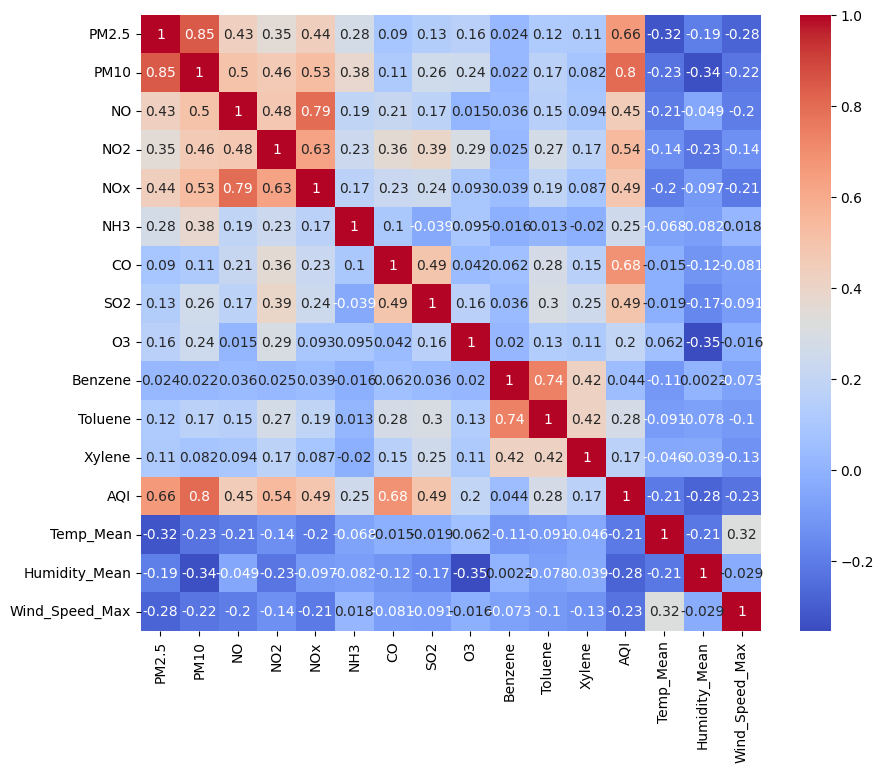

In [29]:
X = df_numeric[selected_features]
y = df_numeric['AQI']
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True)
plt.show()

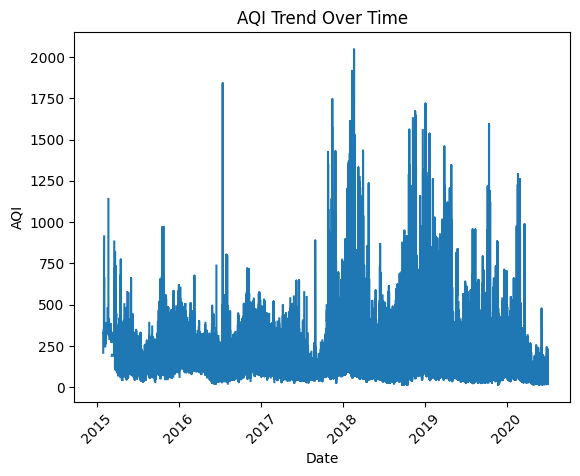

In [30]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by Date (very important for time series)
df = df.sort_values('Date')
plt.figure()
plt.plot(df['Date'], df['AQI'])
plt.title("AQI Trend Over Time")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.xticks(rotation=45)
plt.show()

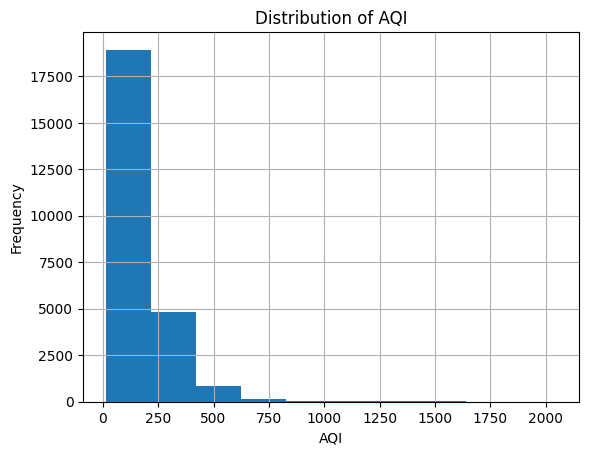

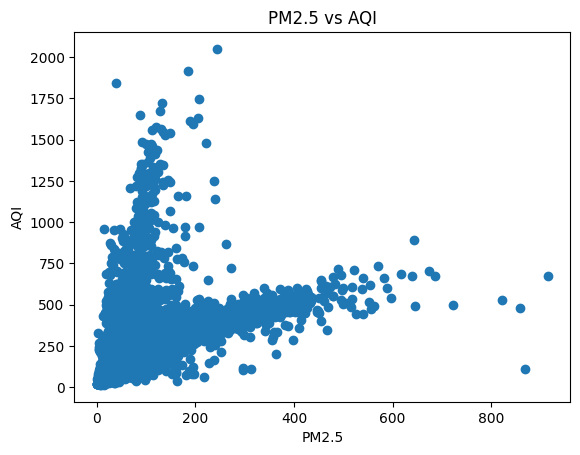

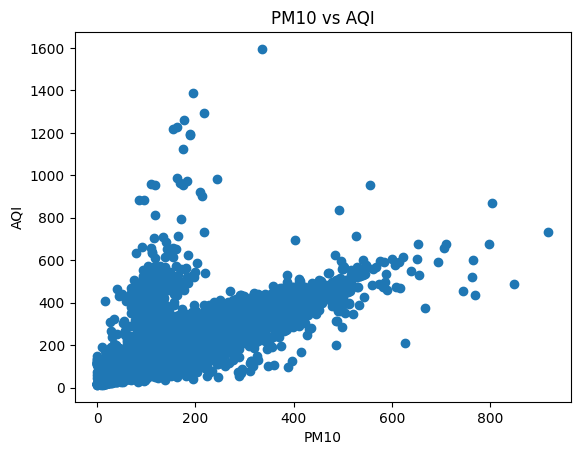

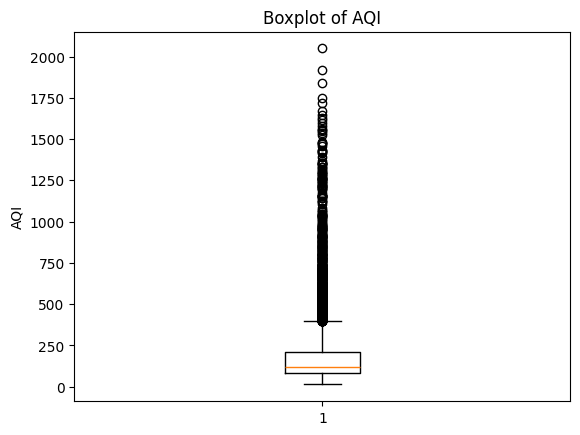

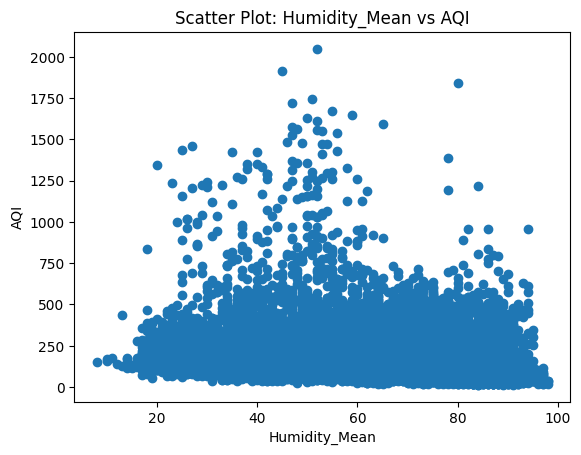

<Figure size 640x480 with 0 Axes>

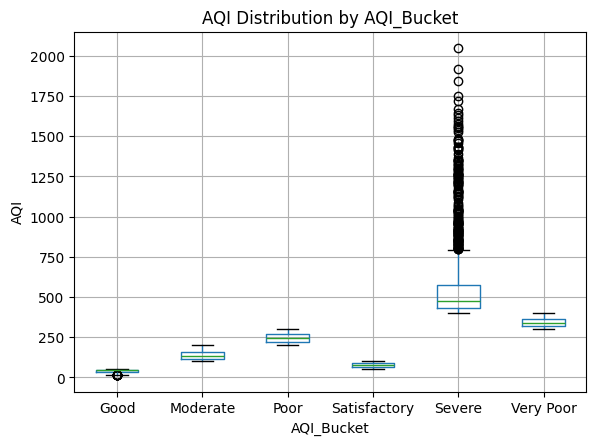

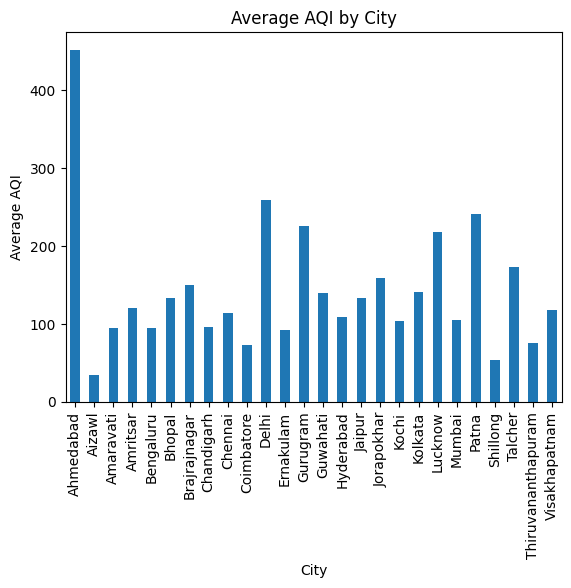

In [31]:
# 1. Histogram - AQI
plt.figure()
df['AQI'].dropna().hist()
plt.title("Distribution of AQI")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()


# 2. Scatter Plot - PM2.5 vs AQI
plt.figure()
plt.scatter(df['PM2.5'], df['AQI'])
plt.title("PM2.5 vs AQI")
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.show()


# 3. Scatter Plot - PM10 vs AQI
plt.figure()
plt.scatter(df['PM10'], df['AQI'])
plt.title("PM10 vs AQI")
plt.xlabel("PM10")
plt.ylabel("AQI")
plt.show()


# 4. Boxplot - AQI (Outlier Detection)
plt.figure()
plt.boxplot(df['AQI'].dropna())
plt.title("Boxplot of AQI")
plt.ylabel("AQI")
plt.show()

plt.figure()
plt.scatter(df['Humidity_Mean'], df['AQI'])
plt.title("Scatter Plot: Humidity_Mean vs AQI")
plt.xlabel("Humidity_Mean")
plt.ylabel("AQI")
plt.show()

plt.figure()
df.boxplot(column='AQI', by='AQI_Bucket')
plt.title("AQI Distribution by AQI_Bucket")
plt.suptitle("")  # removes automatic subtitle
plt.xlabel("AQI_Bucket")
plt.ylabel("AQI")
plt.show()


# Bar Plot: Average AQI by City
# ----------------------------
plt.figure()
df.groupby('City')['AQI'].mean().plot(kind='bar')
plt.title("Average AQI by City")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.show()

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [4]:
df = pd.read_csv('city_day_with_weather_complete.csv')
print(f"  Raw shape: {df.shape}")

  Raw shape: (29531, 19)


In [5]:
# Drop rows where target is missing
df = df.dropna(subset=['AQI'])

In [6]:
# Drop unnecessary columns
cols_to_drop = [c for c in ['AQI_Bucket', 'NH3', 'O3', 'Benzene',
                             'Toluene', 'Xylene'] if c in df.columns]
df = df.drop(columns=cols_to_drop)

# Remove Lucknow (too many missing values)
df = df[df['City'] != 'Lucknow']

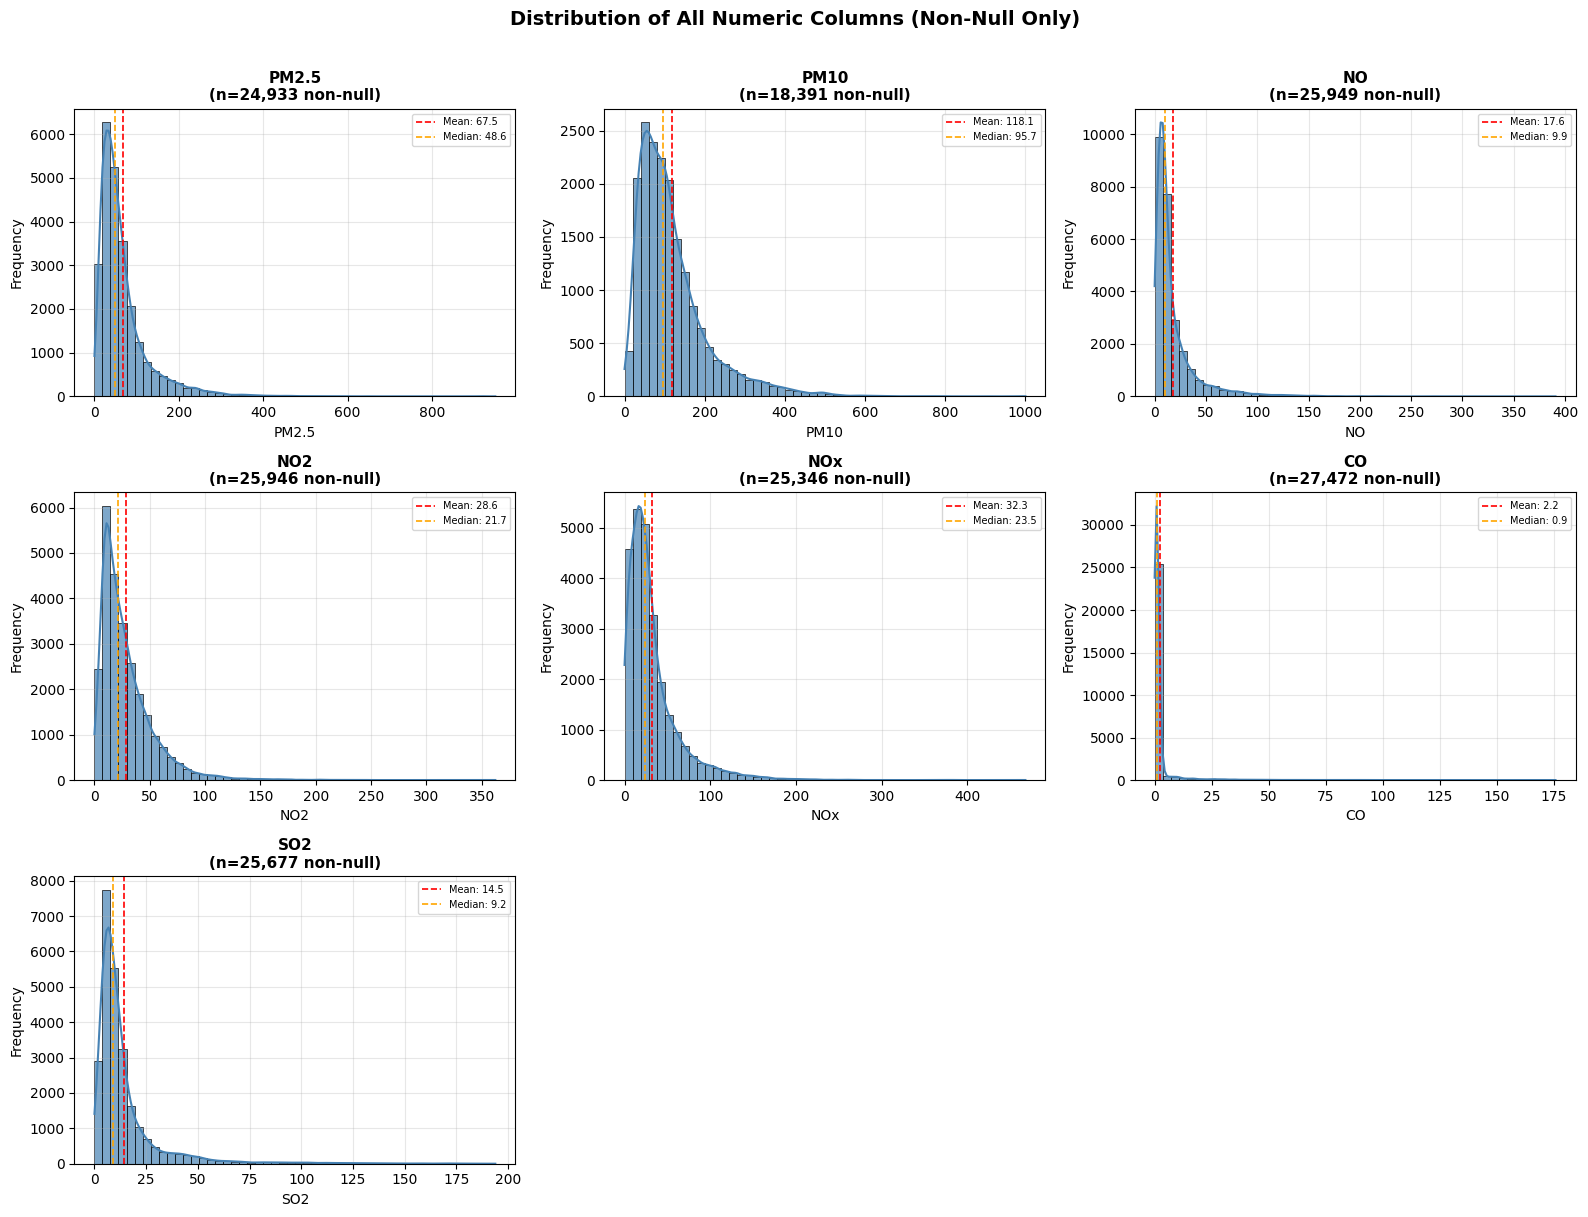

Saved: distributions.png


In [32]:
# Select only numeric columns with non-null values
numeric_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'CO', 'SO2']

ncols = 3
nrows = int(np.ceil(len(numeric_cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    data = df[col].dropna()  # only non-null values
    
    sns.histplot(data, ax=ax, kde=True, color='steelblue', bins=50, alpha=0.7)
    
    ax.set_title(f"{col}\n(n={len(data):,} non-null)", fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.2, label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.2, label=f'Median: {data.median():.1f}')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

# Hide unused subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of All Numeric Columns (Non-Null Only)", 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: distributions.png")

In [7]:
df['Date'] = pd.to_datetime(df['Date'])
print(f"  Clean shape: {df.shape}")
print(f"  Cities: {sorted(df['City'].unique())}")
print(f"  Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")

  Clean shape: (22957, 13)
  Cities: ['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']
  Date range: 2015-01-01 → 2020-07-01


In [8]:
# ══════════════════════════════════════════════════════════
# STEP 2 — FILL NULLS WITH CITY-LEVEL MEDIAN
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 2 — Filling Null Values")
print("=" * 60)

cols_to_fill = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'CO', 'SO2']
cols_to_fill = [c for c in cols_to_fill if c in df.columns]

print("  Nulls before fill:")
print(df[cols_to_fill].isnull().sum().to_string())

for col in cols_to_fill:
    # City-level median first
    df[col] = df.groupby('City')[col].transform(
        lambda x: x.fillna(x.median())
    )
    # Global median fallback
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("\n  Nulls after fill:")
print(df[cols_to_fill].isnull().sum().to_string())


STEP 2 — Filling Null Values
  Nulls before fill:
PM2.5     676
PM10     5193
NO        385
NO2       389
NOx      1552
CO        437
SO2       604

  Nulls after fill:
PM2.5    0
PM10     0
NO       0
NO2      0
NOx      0
CO       0
SO2      0


In [9]:
# ══════════════════════════════════════════════════════════
# STEP 3 — SORT (must happen before lag features)
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 3 — Sorting by City & Date")
print("=" * 60)

df = df.sort_values(by=['City', 'Date']).reset_index(drop=True)
print("  Done.")


STEP 3 — Sorting by City & Date
  Done.


In [10]:
# ══════════════════════════════════════════════════════════
# STEP 4 — FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 4 — Feature Engineering")
print("=" * 60)

# ── Lag & rolling features ─────────────────────────────────
poll_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'CO', 'SO2', 'AQI']
poll_cols = [c for c in poll_cols if c in df.columns]

for col in poll_cols:
    grp = df.groupby('City')[col]

    # Lag features
    df[f'{col}_lag1'] = grp.shift(1)
    df[f'{col}_lag3'] = grp.shift(3)
    df[f'{col}_lag7'] = grp.shift(7)

    # Rolling mean
    df[f'{col}_roll7_mean']  = grp.shift(1).transform(
        lambda x: x.rolling(7,  min_periods=1).mean())
    df[f'{col}_roll30_mean'] = grp.shift(1).transform(
        lambda x: x.rolling(30, min_periods=1).mean())

    # Rolling std (volatility)
    df[f'{col}_roll7_std'] = grp.shift(1).transform(
        lambda x: x.rolling(7, min_periods=1).std())

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"  Shape after lag features: {df.shape}")

# ── Date parts ─────────────────────────────────────────────
df['year']       = df['Date'].dt.year
df['month']      = df['Date'].dt.month
df['day']        = df['Date'].dt.day
df['day_of_week']= df['Date'].dt.dayofweek

# ── Cyclical encoding for month ───────────────────────────
df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)


STEP 4 — Feature Engineering
  Shape after lag features: (22782, 61)


In [11]:
# ══════════════════════════════════════════════════════════
# STEP 5 — DEFINE X AND y
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 5 — Defining Features & Target")
print("=" * 60)

y = df['AQI']
X = df.drop(columns=['AQI', 'Date']).copy()

print(f"  Total features : {X.shape[1]}")
print(f"  Total samples  : {X.shape[0]}")
print("\n  Feature list:")
for i, col in enumerate(X.columns, 1):
    print(f"    {i:3}. {col}")


STEP 5 — Defining Features & Target
  Total features : 65
  Total samples  : 22782

  Feature list:
      1. City
      2. PM2.5
      3. PM10
      4. NO
      5. NO2
      6. NOx
      7. CO
      8. SO2
      9. Temp_Mean
     10. Humidity_Mean
     11. Wind_Speed_Max
     12. PM2.5_lag1
     13. PM2.5_lag3
     14. PM2.5_lag7
     15. PM2.5_roll7_mean
     16. PM2.5_roll30_mean
     17. PM2.5_roll7_std
     18. PM10_lag1
     19. PM10_lag3
     20. PM10_lag7
     21. PM10_roll7_mean
     22. PM10_roll30_mean
     23. PM10_roll7_std
     24. NO_lag1
     25. NO_lag3
     26. NO_lag7
     27. NO_roll7_mean
     28. NO_roll30_mean
     29. NO_roll7_std
     30. NO2_lag1
     31. NO2_lag3
     32. NO2_lag7
     33. NO2_roll7_mean
     34. NO2_roll30_mean
     35. NO2_roll7_std
     36. NOx_lag1
     37. NOx_lag3
     38. NOx_lag7
     39. NOx_roll7_mean
     40. NOx_roll30_mean
     41. NOx_roll7_std
     42. CO_lag1
     43. CO_lag3
     44. CO_lag7
     45. CO_roll7_mean
     46. CO

In [12]:
# ══════════════════════════════════════════════════════════
# STEP 6 — TRAIN / TEST SPLIT (time-based)
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 6 — Train/Test Split (80/20 time-based)")
print("=" * 60)

split_index = int(0.8 * len(X))
X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"  Train size : {len(X_train):,}")
print(f"  Test size  : {len(X_test):,}")


STEP 6 — Train/Test Split (80/20 time-based)
  Train size : 18,225
  Test size  : 4,557


In [13]:
# ══════════════════════════════════════════════════════════
# STEP 7 — PREPROCESSOR
# ══════════════════════════════════════════════════════════
categorical_features = ['City']
numeric_features     = [c for c in X.columns if c != 'City']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                      numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [15]:
# ══════════════════════════════════════════════════════════
# STEP 8 — TRAIN ALL MODELS
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 8 — Training Models")
print("=" * 60)

ridge_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(n_estimators=100, learning_rate=0.1,
                           random_state=42, n_jobs=-1))
])

lgbm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMRegressor(n_estimators=500, learning_rate=0.05,
                            num_leaves=31, random_state=42,
                            n_jobs=-1, verbose=-1))
])

models = {
    "Ridge Regression": ridge_model,
    "Random Forest":    rf_model,
    "XGBoost":          xgb_model,
    "LightGBM":         lgbm_model,
}

results  = []
all_preds = {}

for name, model in models.items():
    print(f"  Training {name} ...", end=" ", flush=True)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    all_preds[name] = y_pred

    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-5))) * 100

    results.append([name, round(mse,4), round(rmse,4),
                    round(mae,4), round(r2,6), round(mape,4)])
    print("done")


STEP 8 — Training Models
  Training Ridge Regression ... done
  Training Random Forest ... done
  Training XGBoost ... done
  Training LightGBM ... done


In [16]:
# ══════════════════════════════════════════════════════════
# STEP 9 — COMPARE ACCURACY
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 9 — Model Comparison")
print("=" * 60)

results_df = pd.DataFrame(
    results, columns=["Model", "MSE", "RMSE", "MAE", "R2", "MAPE%"]
).sort_values("RMSE").reset_index(drop=True)

print(results_df.to_string(index=False))
results_df.to_csv("model_comparison.csv", index=False)
print("\n  Saved: model_comparison.csv")

best_model_name = results_df.iloc[0]["Model"]
print(f"\n  🏆 Best model: {best_model_name}")


STEP 9 — Model Comparison
           Model      MSE    RMSE     MAE       R2   MAPE%
        LightGBM 457.2847 21.3842 14.1247 0.962070 11.7286
   Random Forest 480.4664 21.9195 14.3988 0.960147 12.3329
         XGBoost 491.8256 22.1771 14.4540 0.959205 12.3617
Ridge Regression 646.8218 25.4327 17.1459 0.946349 13.2479

  Saved: model_comparison.csv

  🏆 Best model: LightGBM



STEP 10 — Plotting Accuracy


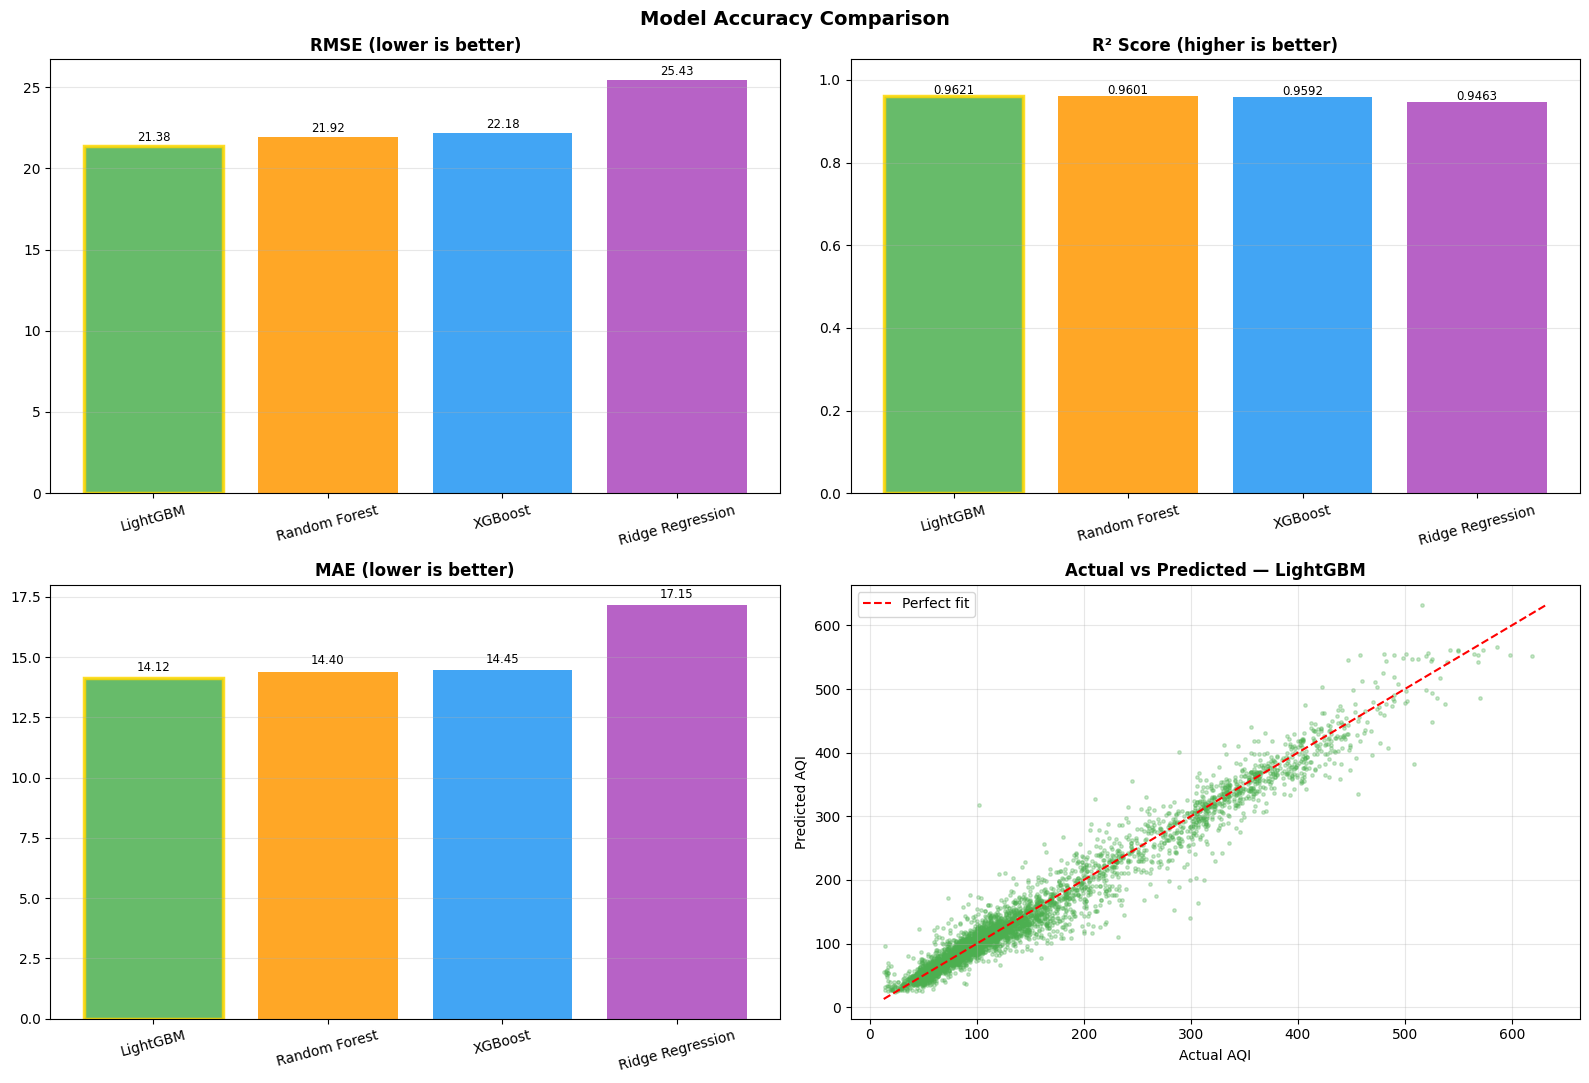

  Saved: model_comparison_plot.png


In [17]:
# ══════════════════════════════════════════════════════════
# STEP 10 — ACCURACY PLOTS  (updated for 4 models)
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 10 — Plotting Accuracy")
print("=" * 60)

MODEL_COLORS = {
    "Ridge Regression": "#AB47BC",
    "Random Forest":    "#FF9800",
    "XGBoost":          "#2196F3",
    "LightGBM":         "#4CAF50",   # ← green
}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Model Accuracy Comparison", fontsize=14, fontweight="bold")

model_names = results_df["Model"].tolist()
colors      = [MODEL_COLORS[m] for m in model_names]

def annotate_bars(ax, bars, values, fmt=".2f", offset=0.3):
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + offset,
                f"{val:{fmt}}", ha="center", fontsize=8.5)

# RMSE
ax = axes[0, 0]
bars = ax.bar(model_names, results_df["RMSE"], color=colors, alpha=0.85)
ax.set_title("RMSE (lower is better)", fontweight="bold")
annotate_bars(ax, bars, results_df["RMSE"])
bars[0].set_edgecolor("gold"); bars[0].set_linewidth(2.5)
ax.tick_params(axis='x', rotation=15)
ax.grid(axis="y", alpha=0.3)

# R²
ax = axes[0, 1]
bars = ax.bar(model_names, results_df["R2"], color=colors, alpha=0.85)
ax.set_title("R² Score (higher is better)", fontweight="bold")
ax.set_ylim(0, 1.05)
annotate_bars(ax, bars, results_df["R2"], fmt=".4f", offset=0.005)
bars[0].set_edgecolor("gold"); bars[0].set_linewidth(2.5)
ax.tick_params(axis='x', rotation=15)
ax.grid(axis="y", alpha=0.3)

# MAE
ax = axes[1, 0]
bars = ax.bar(model_names, results_df["MAE"], color=colors, alpha=0.85)
ax.set_title("MAE (lower is better)", fontweight="bold")
annotate_bars(ax, bars, results_df["MAE"])
bars[0].set_edgecolor("gold"); bars[0].set_linewidth(2.5)
ax.tick_params(axis='x', rotation=15)
ax.grid(axis="y", alpha=0.3)

# Actual vs Predicted (best model)
ax = axes[1, 1]
bp = all_preds[best_model_name]
ax.scatter(y_test, bp, alpha=0.3, s=6, color=MODEL_COLORS[best_model_name])
lims = [min(y_test.min(), bp.min()), max(y_test.max(), bp.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect fit")
ax.set_xlabel("Actual AQI"); ax.set_ylabel("Predicted AQI")
ax.set_title(f"Actual vs Predicted — {best_model_name}", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("model_comparison_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: model_comparison_plot.png")

In [18]:
# ══════════════════════════════════════════════════════════
# STEP 8.5 — K-FOLD CROSS VALIDATION (evaluate all models)
# ══════════════════════════════════════════════════════════
from sklearn.model_selection import KFold, cross_validate
from sklearn.model_selection import TimeSeriesSplit
from lightgbm import LGBMRegressor

print("\n" + "=" * 60)
print("STEP 8.5 — K-Fold Cross Validation (k=5)")
print("=" * 60)

tscv = TimeSeriesSplit(n_splits=5)

cv_results = []

for name, model in models.items():
    print(f"  Running K-Fold on {name} ...", end=" ", flush=True)

    scores = cross_validate(
        model, X_train, y_train,
        cv=tscv,
        scoring={
            'rmse': 'neg_root_mean_squared_error',
            'mse':  'neg_mean_squared_error',
            'mae':  'neg_mean_absolute_error',
            'r2':   'r2'
        },
        n_jobs=-1
    )

    cv_results.append({
        "Model":        name,
        "CV_RMSE_mean": round(-scores['test_rmse'].mean(), 4),
        "CV_RMSE_std":  round( scores['test_rmse'].std(),  4),
        "CV_MSE_mean":  round(-scores['test_mse'].mean(),  4),
        "CV_MAE_mean":  round(-scores['test_mae'].mean(),  4),
        "CV_R2_mean":   round( scores['test_r2'].mean(),   6),
    })
    print("done")

cv_df = pd.DataFrame(cv_results).sort_values("CV_RMSE_mean").reset_index(drop=True)

print("\n  K-Fold CV Results:")
print(cv_df.to_string(index=False))
cv_df.to_csv("kfold_cv_results.csv", index=False)
print("\n  Saved: kfold_cv_results.csv")


STEP 8.5 — K-Fold Cross Validation (k=5)
  Running K-Fold on Ridge Regression ... done
  Running K-Fold on Random Forest ... done
  Running K-Fold on XGBoost ... done
  Running K-Fold on LightGBM ... done

  K-Fold CV Results:
           Model  CV_RMSE_mean  CV_RMSE_std  CV_MSE_mean  CV_MAE_mean  CV_R2_mean
Ridge Regression       33.3344       7.1206    1161.8838      21.2022    0.805088
        LightGBM       33.4764       8.7000    1196.3607      18.8767    0.785717
         XGBoost       33.5324       8.6186    1198.6995      18.5569    0.798002
   Random Forest       34.4813       7.0812    1239.1055      18.9271    0.791215

  Saved: kfold_cv_results.csv


In [23]:
# ══════════════════════════════════════════════════════════
# STEP 11a — GRIDSEARCHCV: Random Forest
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 11a — GridSearchCV: Random Forest")
print("=" * 60)

param_grid_rf = {
    'model__n_estimators':      [300, 500],
    'model__max_depth':         [15, 20, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf':  [1, 2],
    'model__max_features':      [0.6, 0.8, 'sqrt'],
}

grid_rf = GridSearchCV(
    rf_model, param_grid_rf,
    cv=tscv, scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=1
)

print("  Running GridSearchCV (this may take a few minutes)...")
grid_rf.fit(X_train, y_train)

y_pred_rf_tuned = grid_rf.predict(X_test)
rf_tuned_mse  = mean_squared_error(y_test, y_pred_rf_tuned)
rf_tuned_rmse = np.sqrt(rf_tuned_mse)
rf_tuned_mae  = mean_absolute_error(y_test, y_pred_rf_tuned)
rf_tuned_r2   = r2_score(y_test, y_pred_rf_tuned)

print(f"\n  Best params : {grid_rf.best_params_}")
print(f"  MSE         : {rf_tuned_mse:.4f}")
print(f"  RMSE        : {rf_tuned_rmse:.4f}")
print(f"  MAE         : {rf_tuned_mae:.4f}")
print(f"  R²          : {rf_tuned_r2:.6f}")


STEP 11a — GridSearchCV: Random Forest
  Running GridSearchCV (this may take a few minutes)...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

  Best params : {'model__max_depth': 15, 'model__max_features': 0.6, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 500}
  MSE         : 444.9316
  RMSE        : 21.0934
  MAE         : 13.8017
  R²          : 0.963095


In [20]:
# ══════════════════════════════════════════════════════════
# STEP 11b — GRIDSEARCHCV: XGBoost
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 11b — GridSearchCV: XGBoost")
print("=" * 60)

param_grid_xgb = {
    'model__n_estimators':     [300, 500],
    'model__max_depth':        [5, 7, 9],
    'model__learning_rate':    [0.01, 0.05, 0.1],
    'model__subsample':        [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
}

grid_xgb = GridSearchCV(
    xgb_model, param_grid_xgb,
    cv=tscv, scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=1
)

print("  Running GridSearchCV (this may take a few minutes)...")
grid_xgb.fit(X_train, y_train)

y_pred_xgb_tuned = grid_xgb.predict(X_test)
xgb_tuned_mse  = mean_squared_error(y_test, y_pred_xgb_tuned)
xgb_tuned_rmse = np.sqrt(xgb_tuned_mse)
xgb_tuned_mae  = mean_absolute_error(y_test, y_pred_xgb_tuned)
xgb_tuned_r2   = r2_score(y_test, y_pred_xgb_tuned)

print(f"\n  Best params : {grid_xgb.best_params_}")
print(f"  MSE         : {xgb_tuned_mse:.4f}")
print(f"  RMSE        : {xgb_tuned_rmse:.4f}")
print(f"  MAE         : {xgb_tuned_mae:.4f}")
print(f"  R²          : {xgb_tuned_r2:.6f}")


STEP 11b — GridSearchCV: XGBoost
  Running GridSearchCV (this may take a few minutes)...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

  Best params : {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.01, 'model__max_depth': 7, 'model__n_estimators': 500, 'model__subsample': 0.8}
  MSE         : 457.8346
  RMSE        : 21.3971
  MAE         : 14.0446
  R²          : 0.962024


In [21]:
# ══════════════════════════════════════════════════════════
# STEP 11c — GRIDSEARCHCV: Ridge
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 11c — GridSearchCV: Ridge")
print("=" * 60)

param_grid_ridge = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
}

grid_ridge = GridSearchCV(
    ridge_model, param_grid_ridge,
    cv=tscv, scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=1
)

print("  Running GridSearchCV...")
grid_ridge.fit(X_train, y_train)

y_pred_ridge_tuned = grid_ridge.predict(X_test)
ridge_tuned_mse  = mean_squared_error(y_test, y_pred_ridge_tuned)
ridge_tuned_rmse = np.sqrt(ridge_tuned_mse)
ridge_tuned_mae  = mean_absolute_error(y_test, y_pred_ridge_tuned)
ridge_tuned_r2   = r2_score(y_test, y_pred_ridge_tuned)

print(f"\n  Best params : {grid_ridge.best_params_}")
print(f"  MSE         : {ridge_tuned_mse:.4f}")
print(f"  RMSE        : {ridge_tuned_rmse:.4f}")
print(f"  MAE         : {ridge_tuned_mae:.4f}")
print(f"  R²          : {ridge_tuned_r2:.6f}")


STEP 11c — GridSearchCV: Ridge
  Running GridSearchCV...
Fitting 5 folds for each of 6 candidates, totalling 30 fits

  Best params : {'model__alpha': 0.01}
  MSE         : 646.7117
  RMSE        : 25.4305
  MAE         : 17.1438
  R²          : 0.946358


In [22]:
# ══════════════════════════════════════════════════════════
# STEP 11d — GRIDSEARCHCV: LightGBM
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 11d — GridSearchCV: LightGBM")
print("=" * 60)

param_grid_lgbm = {
    'model__n_estimators':  [300, 500],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__num_leaves':    [31, 63, 127],
    'model__max_depth':     [-1, 10, 20],
    'model__subsample':     [0.8, 1.0],
}

grid_lgbm = GridSearchCV(
    lgbm_model, param_grid_lgbm,
    cv=tscv, scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=1
)

print("  Running GridSearchCV (this may take a few minutes)...")
grid_lgbm.fit(X_train, y_train)

y_pred_lgbm_tuned = grid_lgbm.predict(X_test)
lgbm_tuned_mse  = mean_squared_error(y_test, y_pred_lgbm_tuned)
lgbm_tuned_rmse = np.sqrt(lgbm_tuned_mse)
lgbm_tuned_mae  = mean_absolute_error(y_test, y_pred_lgbm_tuned)
lgbm_tuned_r2   = r2_score(y_test, y_pred_lgbm_tuned)

print(f"\n  Best params : {grid_lgbm.best_params_}")
print(f"  MSE         : {lgbm_tuned_mse:.4f}")
print(f"  RMSE        : {lgbm_tuned_rmse:.4f}")
print(f"  MAE         : {lgbm_tuned_mae:.4f}")
print(f"  R²          : {lgbm_tuned_r2:.6f}")


STEP 11d — GridSearchCV: LightGBM
  Running GridSearchCV (this may take a few minutes)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

  Best params : {'model__learning_rate': 0.01, 'model__max_depth': 10, 'model__n_estimators': 500, 'model__num_leaves': 63, 'model__subsample': 0.8}
  MSE         : 445.5635
  RMSE        : 21.1084
  MAE         : 13.8541
  R²          : 0.963042


In [24]:
# ══════════════════════════════════════════════════════════
# STEP 12 — POST-TUNING SUMMARY (all 4 models)
# ══════════════════════════════════════════════════════════
tuned_summary = pd.DataFrame([
    {"Model": "Random Forest", "MSE": rf_tuned_mse,    "RMSE": rf_tuned_rmse,    "MAE": rf_tuned_mae,    "R2": rf_tuned_r2},
    {"Model": "XGBoost",       "MSE": xgb_tuned_mse,   "RMSE": xgb_tuned_rmse,   "MAE": xgb_tuned_mae,   "R2": xgb_tuned_r2},
    {"Model": "Ridge",         "MSE": ridge_tuned_mse,  "RMSE": ridge_tuned_rmse,  "MAE": ridge_tuned_mae,  "R2": ridge_tuned_r2},
    {"Model": "LightGBM",      "MSE": lgbm_tuned_mse,  "RMSE": lgbm_tuned_rmse,  "MAE": lgbm_tuned_mae,  "R2": lgbm_tuned_r2},
]).sort_values("RMSE").reset_index(drop=True)

print("\n" + "=" * 60)
print("STEP 12 — Post-Tuning Summary (all models)")
print("=" * 60)
print(tuned_summary.to_string(index=False))

tuned_summary.to_csv("gridsearch_tuned_results.csv", index=False)
print("\n  Saved: gridsearch_tuned_results.csv")


STEP 12 — Post-Tuning Summary (all models)
        Model        MSE      RMSE       MAE       R2
Random Forest 444.931567 21.093401 13.801694 0.963095
     LightGBM 445.563490 21.108375 13.854101 0.963042
      XGBoost 457.834646 21.397071 14.044590 0.962024
        Ridge 646.711653 25.430526 17.143780 0.946358

  Saved: gridsearch_tuned_results.csv
